# Optical detector information

## Purpose of this notebook

Goal of this notebook is the demonstrate how to access and use the information from the MicroBooNE light detector.

## Load useful libraries, utilities, and data

Get libraries, utils, and data

In [2]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
try:
    from microboone_utils import nopdets, nplanes, tpcTimeToX, doWiresCross, wireCrossingYZ
    from plot_utils import NormOne
    _HAS_MB_UTILS = True
except Exception as exc:
    _HAS_MB_UTILS = False
    print(f"Using repository fallbacks for microboone_utils/plot_utils ({exc!r})")

    # Fallbacks matched to MicroBooNE-like scales.
    _DRIFT_VELOCITY_CM_PER_US = 0.1101
    _TICK_US = 0.5
    _WIRE0_TO_Y = np.array([0.1, -120.0], dtype=float)
    _WIRE2_TO_Z = np.array([0.3, 0.0], dtype=float)

    def NormOne(v):
        n = len(v)
        return np.ones(n) / n if n > 0 else np.array([])

    def nopdets():
        return 32

    def nplanes():
        return 3

    def tpcTimeToX(t):
        t = np.asarray(t, dtype=float)
        return t * _TICK_US * _DRIFT_VELOCITY_CM_PER_US

    def doWiresCross(_p0, w0, _p1, w1):
        return np.isfinite(w0) and np.isfinite(w1)

    def wireCrossingYZ(_p0, w0, _p1, w1):
        y = _WIRE0_TO_Y[0] * float(w0) + _WIRE0_TO_Y[1]
        z = _WIRE2_TO_Z[0] * float(w1) + _WIRE2_TO_Z[1]
        return y, z

    def configure_optical_geometry_from_ophits(ophits_df):
        global _WIRE0_TO_Y, _WIRE2_TO_Z
        if "hit_channel" not in ophits_df.columns:
            return
        chan = np.arange(32)
        pmt_y = np.array([
            55.267144, 55.962509, 27.555318, -0.850317, -28.561692, -56.620694, -56.447756, 55.442895,
            55.789304, -0.675445, 0.017374, -56.275066, -56.274171, 55.616099, 55.616099, -0.50224,
            -1.021855, -56.100966, -56.100966, 54.750076, 54.749983, -0.675445, -0.84865, -56.96699,
            -56.274171, 55.096391, 55.269595, 27.556793, -0.502415, -28.734833, -56.274171, -56.620838
        ], dtype=float)
        pmt_z = np.array([
            951.85, 911.05, 989.65, 865.45, 990.25, 951.85, 911.95, 751.75,
            710.95, 796.15, 664.15, 752.05, 711.25, 540.85, 500.05, 585.25,
            452.95, 540.55, 500.35, 328.15, 287.95, 373.75, 242.05, 328.45,
            287.65, 128.35, 87.85, 51.25, 173.65, 50.35, 128.05, 87.85
        ], dtype=float)
        ref = (ophits_df.groupby("hit_channel")[["wire_pos_0", "wire_pos_2"]]
               .median().reindex(chan).dropna())
        if len(ref) < 4:
            return
        idx = ref.index.to_numpy(dtype=int)
        x0 = ref["wire_pos_0"].to_numpy(dtype=float)
        x2 = ref["wire_pos_2"].to_numpy(dtype=float)
        _WIRE0_TO_Y = np.polyfit(x0, pmt_y[idx], deg=1)
        _WIRE2_TO_Z = np.polyfit(x2, pmt_z[idx], deg=1)

def barycenter(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if values.size == 0:
        return 0.0
    wsum = weights.sum()
    if not np.isfinite(wsum) or wsum == 0:
        return float(values.mean())
    return float(np.average(values, weights=weights))


In [4]:
import nugraph as ng

In [ ]:
DATA_PATH = "/net/projects2/fermi2526/data/nugraph3-dsi.optical.fix.renamed.gnn.h5"
Data = ng.data.NuGraphDataModule
Model = ng.models.NuGraph3
nudata = Data(model=Model, data_path=DATA_PATH, num_workers=0)

dataset = nudata.test_dataset
nevts = min(2000, len(dataset))

ophit_rows = []
opflash_rows = []
opflashsumpe_rows = []
hit_rows = []

for evt_idx in range(nevts):
    data = dataset[evt_idx]

    # ophit table from node features + ophit->pmt edges
    oph_pos = data['ophit'].pos.cpu().numpy()
    oph_x = data['ophit'].x.cpu().numpy()
    n_oph = oph_pos.shape[0]
    if ('ophit', 'in', 'pmt') in data.edge_types and data['ophit', 'in', 'pmt'].edge_index.numel() > 0:
        e = data['ophit', 'in', 'pmt'].edge_index.cpu().numpy()
        hit_channel = np.zeros(n_oph, dtype=int)
        hit_channel[e[0]] = e[1]
    else:
        hit_channel = np.zeros(n_oph, dtype=int)
    pe = oph_x[:, 3] if oph_x.shape[1] > 3 else np.ones(n_oph, dtype=float)
    peaktime = oph_pos[:, 0] / 80.0
    width = np.full(n_oph, 0.1875, dtype=float)
    sumpe_id = np.where(pe > 0, 0, -1)
    ophit_rows.append(pd.DataFrame({
        'amplitude': pe * 20.0,
        'area': pe * 100.0,
        'hit_channel': hit_channel,
        'hit_id': np.arange(n_oph, dtype=int),
        'pe': pe,
        'peaktime': peaktime,
        'sumpe_id': sumpe_id,
        'width': width,
        'wire_pos_0': oph_pos[:, 0],
        'wire_pos_1': oph_pos[:, 1],
        'wire_pos_2': oph_pos[:, 2],
        'evt_idx': np.full(n_oph, evt_idx, dtype=int),
    }))

    # opflash table from flash node
    flash_pos = data['flash'].pos.cpu().numpy()
    flash_x = data['flash'].x.cpu().numpy()
    n_flash = flash_pos.shape[0]
    if n_flash > 0:
        time = flash_pos[:, 0] / 80.0
        totalpe = flash_x[:, 5] if flash_x.shape[1] > 5 else np.maximum(flash_x.sum(axis=1), 1.0)
        y_center = flash_pos[:, 1]
        z_center = flash_pos[:, 2]
        y_width = np.abs(flash_x[:, 8]) if flash_x.shape[1] > 8 else np.full(n_flash, 10.0)
        z_width = np.abs(flash_x[:, 9]) if flash_x.shape[1] > 9 else np.full(n_flash, 50.0)
        opflash_rows.append(pd.DataFrame({
            'time': time,
            'totalpe': totalpe,
            'y_center': y_center,
            'z_center': z_center,
            'y_width': y_width,
            'z_width': z_width,
            'wire_pos_0': (y_center - _WIRE0_TO_Y[1]) / _WIRE0_TO_Y[0],
            'wire_pos_2': (z_center - _WIRE2_TO_Z[1]) / _WIRE2_TO_Z[0],
            'slice_id': np.zeros(n_flash, dtype=int),
            'evt_idx': np.full(n_flash, evt_idx, dtype=int),
        }))

    # opflashsumpe table from pmt node
    pmt_x = data['pmt'].x.cpu().numpy()
    n_pmt = pmt_x.shape[0]
    if n_pmt > 0:
        sumpe = pmt_x[:, 3] if pmt_x.shape[1] > 3 else np.zeros(n_pmt, dtype=float)
        opflashsumpe_rows.append(pd.DataFrame({
            'pmt_channel': np.arange(n_pmt, dtype=int),
            'sumpe': sumpe,
            'evt_idx': np.full(n_pmt, evt_idx, dtype=int),
        }))

    # hit table subset needed by downstream notebook cells
    hit_pos = data['hit'].pos.cpu().numpy()
    hit_plane = data['hit'].plane.cpu().numpy()
    hit_x = data['hit'].x.cpu().numpy()
    n_hit = hit_pos.shape[0]
    integral = hit_x[:, 2] if hit_x.shape[1] > 2 else np.ones(n_hit, dtype=float)
    if hasattr(data['hit'], 'id'):
        hit_id = data['hit'].id.cpu().numpy()
    else:
        hit_id = np.arange(n_hit, dtype=int)
    if hasattr(data['hit'], 'y_semantic'):
        y_sem = data['hit'].y_semantic.cpu().numpy()
        g4_id = np.where(y_sem > 0, 1, -1)
    else:
        g4_id = np.full(n_hit, -1, dtype=int)
    hit_rows.append(pd.DataFrame({
        'evt_idx': np.full(n_hit, evt_idx, dtype=int),
        'hit_id': hit_id,
        'local_plane': hit_plane,
        'local_wire': hit_pos[:, 0],
        'local_time': hit_pos[:, 1],
        'integral': integral,
        'slice_id': np.zeros(n_hit, dtype=int),
        'g4_id': g4_id,
    }))

ophits = pd.concat(ophit_rows, ignore_index=True) if ophit_rows else pd.DataFrame()
opflash = pd.concat(opflash_rows, ignore_index=True) if opflash_rows else pd.DataFrame()
opflashsumpe = pd.concat(opflashsumpe_rows, ignore_index=True) if opflashsumpe_rows else pd.DataFrame()
hits = pd.concat(hit_rows, ignore_index=True) if hit_rows else pd.DataFrame()

if not _HAS_MB_UTILS and len(ophits):
    configure_optical_geometry_from_ophits(ophits)

print(f"Loaded {nevts} events from {DATA_PATH} via NuGraphDataModule")
print(f"ophits={len(ophits)} opflash={len(opflash)} opflashsumpe={len(opflashsumpe)} hits={len(hits)}")

## Exploring OpHits and OpFlashes

We first take a look at the content of the ophit and opflash tables, and plot some basic quantities. The optical detector system consists of 32 photo multiplier tubes (PMT). Optical information stored in this tables is based on light recorded for a duration of 1500 samples (23.4 µs) which is opened by the beam-gate signal received on the trigger board. Neutrinos are expected to arrive ∼ 4 µs after this window is opened.

In [6]:
ophits.loc[ophits["pe"]<0,"pe"] = 0
ophits

,amplitude,area,hit_channel,hit_id,pe,peaktime,sumpe_id,width,wire_pos_0,wire_pos_1,wire_pos_2,evt_idx
0,316.428558,1582.142822,0,0,15.821428,22.0625,0,0.1875,1765.0,2079.0,3172.0,0
1,90.583084,452.915436,0,1,4.529154,22.0625,0,0.1875,1765.0,2079.0,3172.0,0
2,644.720459,3223.602295,0,2,32.236023,22.0625,0,0.1875,1765.0,2079.0,3172.0,0
3,294.571442,1472.857178,0,3,14.728572,22.0625,0,0.1875,1765.0,2079.0,3172.0,0
4,480.000000,2400.000000,0,4,24.000000,21.1875,0,0.1875,1695.0,2012.0,3036.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
888740,302.184875,1510.924316,26,435,15.109243,4.0625,0,0.1875,325.0,638.0,292.0,1999
888741,563.909790,2819.548828,26,436,28.195488,4.0625,0,0.1875,325.0,638.0,292.0,1999
888742,462.255615,2311.278076,0,437,23.112782,4.0625,0,0.1875,325.0,638.0,292.0,1999
888743,418.809509,2094.047607,0,438,20.940475,4.0625,0,0.1875,325.0,638.0,292.0,1999


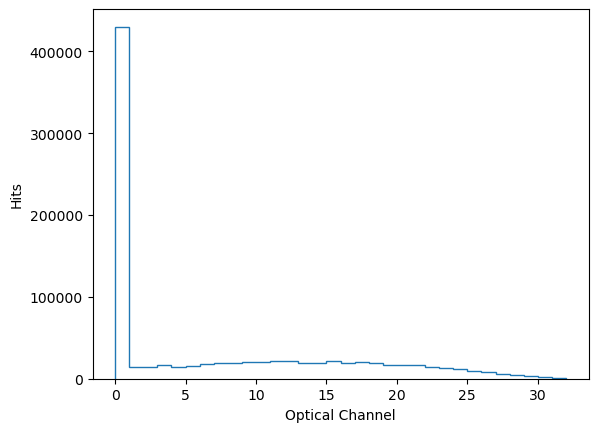

In [7]:
plt.hist(ophits['hit_channel'],np.linspace(0,nopdets(),nopdets()+1),histtype='step')
plt.xlabel('Optical Channel')
plt.ylabel('Hits')
plt.show()

Hits from different PMTs are combined into flashes, which are meant to capture the light created by each neutrino interaction. Since argon produces both prompt and delayed light, hits from a ~8 µs window are integrated into a flash.

<>:4: SyntaxWarning:

invalid escape sequence '\m'

<>:4: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_785114/1806947764.py:4: SyntaxWarning:

invalid escape sequence '\m'



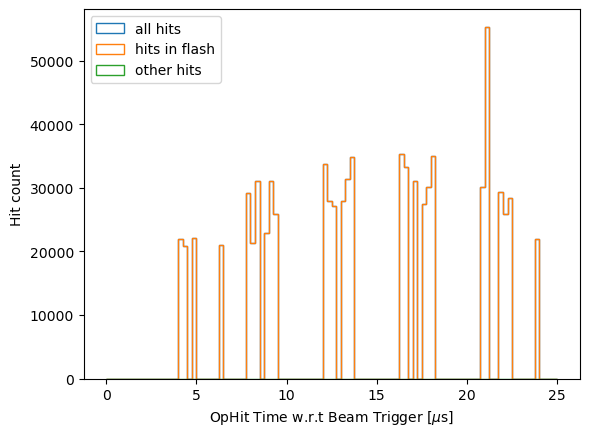

In [8]:
plt.hist(ophits['peaktime'],np.linspace(0,25,101),histtype='step',label='all hits')
plt.hist(ophits.query('sumpe_id>=0')['peaktime'],np.linspace(0,25,101),histtype='step',label='hits in flash')
plt.hist(ophits.query('sumpe_id<0')['peaktime'],np.linspace(0,25,101),histtype='step',label='other hits')
plt.xlabel('OpHit Time w.r.t Beam Trigger [$\mu$s]')
plt.ylabel('Hit count')
plt.legend()
plt.show()

The flash in the beam window with the largest total number of collected photo electrons (PE) is assumed to be the flash associated with the neutrino interaction. PEs used in flashes are the sum of the PE in each hit after baseline subtraction and calibration.

In [9]:
opflash

,time,totalpe,y_center,z_center,y_width,z_width,wire_pos_0,wire_pos_2,slice_id,evt_idx
0,9.425000,1436.683228,905.0,988.0,296.539032,87.287483,10250.0,3293.333333,0,0
1,10.387500,3351.243652,811.0,971.0,291.605652,134.392609,9310.0,3236.666667,0,1
2,18.112499,836.921448,1533.0,2310.0,693.353821,123.869499,16530.0,7700.000000,0,2
3,18.387501,2069.491943,1390.0,2190.0,657.133423,128.973953,15100.0,7300.000000,0,3
4,23.062500,1160.735840,1899.0,3072.0,921.988770,104.446678,20190.0,10240.000000,0,4
...,...,...,...,...,...,...,...,...,...,...
2360,22.687500,2711.307861,1751.0,2894.0,868.525757,127.404137,18710.0,9646.666667,0,1996
2361,10.250000,8390.613281,746.0,895.0,268.630707,166.783890,8660.0,2983.333333,0,1997
2362,8.637500,427.516846,498.0,517.0,155.466019,106.173561,6180.0,1723.333333,0,1997
2363,15.012500,1655.052979,1199.0,1728.0,518.702881,212.622498,13190.0,5760.000000,0,1998


<>:5: SyntaxWarning:

invalid escape sequence '\m'

<>:5: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_785114/1628079543.py:5: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_785114/1628079543.py:1: FutureWarning:

The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.



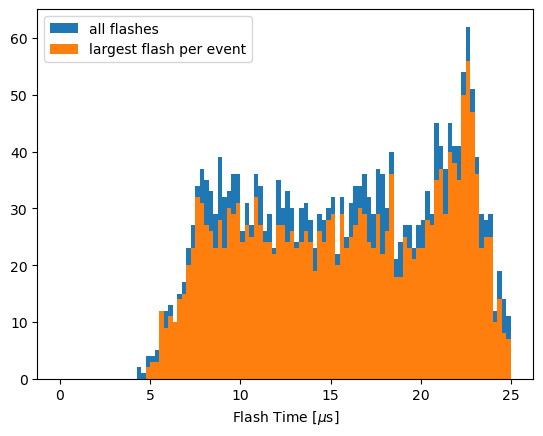

In [10]:
largestpeflashmask = opflash.groupby(["evt_idx"])["totalpe"].transform(max) == opflash["totalpe"]

plt.hist(opflash['time'],np.linspace(0,25,101),label='all flashes')
plt.hist(opflash[largestpeflashmask]["time"],np.linspace(0,25,101),label='largest flash per event')
plt.xlabel('Flash Time [$\mu$s]')
plt.legend()
plt.show()

## Digging into one event

We can visualize the optical information for a single event. First we need to select an event to look into.

In [11]:
ievt = 31

evtophits = ophits.query('evt_idx==%i'%ievt)
evtopflash = opflash.query('evt_idx==%i'%ievt)

In [12]:
evtopflashsumpe = opflashsumpe.query('evt_idx==%i'%ievt)
evtopflashsumpe

,pmt_channel,sumpe,evt_idx
826,0,0.087684,31
827,1,1.860593,31
828,2,7.142740,31
829,3,0.477912,31
830,4,0.303419,31
831,5,0.070872,31
832,6,12.626867,31
833,7,13.651403,31
834,8,13.393376,31
835,9,53.847759,31


Create a data frame with the relevant flash information for this event, and print the information per PMT:

In [13]:
flashbyopdet = pd.DataFrame()
flashbyopdet["channel"] = [i for i in range(0,nopdets())]
flashbyopdet["hitpesum"] = [evtophits.query("sumpe_id>=0 and hit_channel==%i"%i)["pe"].sum() for i in range(0,nopdets())]
flashbyopdet["wire_pos_0"] = [evtophits.query("sumpe_id>=0 and hit_channel==%i"%i)["wire_pos_0"].unique()[0] if len(evtophits.query("sumpe_id>=0 and hit_channel==%i"%i))>0 else 0 for i in range(0,nopdets())]
flashbyopdet["wire_pos_1"] = [evtophits.query("sumpe_id>=0 and hit_channel==%i"%i)["wire_pos_1"].unique()[0] if len(evtophits.query("sumpe_id>=0 and hit_channel==%i"%i))>0 else 0 for i in range(0,nopdets())]
flashbyopdet["wire_pos_2"] = [evtophits.query("sumpe_id>=0 and hit_channel==%i"%i)["wire_pos_2"].unique()[0] if len(evtophits.query("sumpe_id>=0 and hit_channel==%i"%i))>0 else 0 for i in range(0,nopdets())]
flashbyopdet["flashpe"] = [ evtopflashsumpe.query('pmt_channel==%i'%i)['sumpe'].iloc[0] if len(evtopflashsumpe.query('pmt_channel==%i'%i)) else 0 for i in range(0,nopdets())]
flashbyopdet['flash_hit_y'] = flashbyopdet.apply(lambda x: wireCrossingYZ(0,x.wire_pos_0,2,x.wire_pos_2)[0], axis=1)
flashbyopdet['flash_hit_z'] = flashbyopdet.apply(lambda x: wireCrossingYZ(0,x.wire_pos_0,2,x.wire_pos_2)[1], axis=1)
flashbyopdet[["channel","hitpesum","wire_pos_0","wire_pos_1","wire_pos_2","flash_hit_y","flash_hit_z","flashpe"]]

,channel,hitpesum,wire_pos_0,wire_pos_1,wire_pos_2,flash_hit_y,flash_hit_z,flashpe
0,0,2651.995117,1765.0,2079.0,3172.0,-9.555726,966.910132,0.087684
1,1,76.176514,1908.0,2062.0,3298.0,-11.769719,1003.026239,1.860593
2,2,143.614746,1783.0,1773.0,2884.0,-9.834411,884.359032,7.142740
3,3,55.447449,2071.0,1900.0,3300.0,-14.293360,1003.599510,0.477912
4,4,53.694267,2088.0,1756.0,3172.0,-14.556562,966.910132,0.303419
5,5,45.510513,2021.0,1690.0,3039.0,-13.519237,928.787575,0.070872
6,6,317.353912,1431.0,1746.0,2505.0,-4.384583,775.724077,12.626867
7,7,296.392883,1362.0,1679.0,2369.0,-3.316293,736.741613,13.651403
8,8,242.268311,1667.0,1658.0,2653.0,-8.038445,818.146170,13.393376
9,9,530.379883,1445.0,1439.0,2213.0,-4.601338,692.026433,53.847759


Plot the position of each photo multiplier tube (PMT) used in the flash, with size and color weighted by the number of photo electrons (PE) collected in the PMT. Both in cartesian coordinates and wire number. We can also overlay the flash barycenter and width (rms).

In [25]:
fig = px.scatter(flashbyopdet, x="flash_hit_z", y="flash_hit_y", color="flashpe", size="flashpe",range_x=(-10,1040),range_y=(-120,120),
                 labels={
                     "flash_hit_z": "z [cm]",
                     "flash_hit_y": "y [cm]",
                     "flashpe": "PE"
                 },
                 title="opflash plot with barycenter (cartesian coordinates)")
fig.add_scatter(x=evtopflash['z_center'], y=evtopflash['y_center'],name='barycenter',showlegend=False,\
               error_x=dict(type='data',array=evtopflash['z_width'],visible=True),\
               error_y=dict(type='data',array=evtopflash['y_width'],visible=True))
fig.show()

# Weighted average calculation
def calc_barycenter(values, weights):
    return float(np.average(values, weights=weights))

# Calculate coordinates dynamically
bary_x = calc_barycenter(flashbyopdet['wire_pos_2'], flashbyopdet['flashpe'])
bary_y = calc_barycenter(flashbyopdet['wire_pos_0'], flashbyopdet['flashpe'])

x_err = calc_width(flashbyopdet['wire_pos_2'], flashbyopdet['flashpe'])
y_err = calc_width(flashbyopdet['wire_pos_0'], flashbyopdet['flashpe'])

# Base scatter plot
fig = px.scatter(
    flashbyopdet, 
    x="wire_pos_2", 
    y="wire_pos_0", 
    color="flashpe", 
    size="flashpe",
    labels={
        "wire_pos_2": "plane 2 wire",
        "wire_pos_0": "plane 0 wire",
        "flashpe": "PE"
    },
    title="opflash plot with barycenter (wire coordinates)"
)

# Place barycenter directly on calculated coordinates
fig.add_scatter(
    x=[bary_x], 
    y=[bary_y], 
    name='barycenter', 
    mode='markers',
    marker=dict(symbol='cross', size=10, color='red'),
    showlegend=True,
    error_x=dict(type='data', array=[x_err], symmetric=True, visible=True),
    error_y=dict(type='data', array=[y_err], symmetric=True, visible=True)
)

fig.show()

## Comparison to Pandora slices

Fundamental usage of light information is to identify the neutrino interactino, happening in-time with the beam, from cosmic-induced interactions, which take place at any time. Here we explore different metrics for associating the in-time flash with the correct set of hits.

First we need to merge the hit information (including information from simulation and from pandora).

In [15]:
hits = hits.copy()
hits['g4_id'] = hits['g4_id'].fillna(-1)
hits = hits.fillna(0)

In [16]:
# pandoraHit_table is not present in .gnn.h5 files; keep synthesized hits as-is.
hits = hits.copy()

In [17]:
nuhits = hits[hits['g4_id']>=0].groupby(["evt_idx","slice_id"]).size().reset_index().rename(columns={0:'nuhits'})
slhits = hits.groupby(["evt_idx","slice_id"]).size().reset_index().rename(columns={0:'slicehits'})

slhits = slhits.merge(nuhits, on=["evt_idx","slice_id"], how="left")
slhits = slhits.fillna(0)

Now we compute the barycenter in wire coordinates per each slice and merge with the flash data frame. We can plot the difference between the flash barycenter and the slice in plane 2 wire coordinates, for slices which are mostly made of hits from the neutrino interaction and slices that are mostly from cosmics.

In [ ]:
sl_hits_baryc = hits[["evt_idx","slice_id"]].drop_duplicates()

for p in range(0,nplanes()):
    slhitsbyevt_p = hits.query('local_plane==%i'%p).groupby(["evt_idx","slice_id"])
    sl_hits_baryc_p = slhitsbyevt_p.apply(lambda x: barycenter(x.local_wire,x.integral)).reset_index().rename(columns={0:'sl_hits_baryc_%i'%p})
    sl_hits_baryc = sl_hits_baryc.merge(sl_hits_baryc_p, on=["evt_idx","slice_id"], how="right")

opflash = opflash.merge(sl_hits_baryc, on=["evt_idx", "slice_id"], how="right")
opflash = opflash.merge(slhits, on=["evt_idx","slice_id"], how="left")

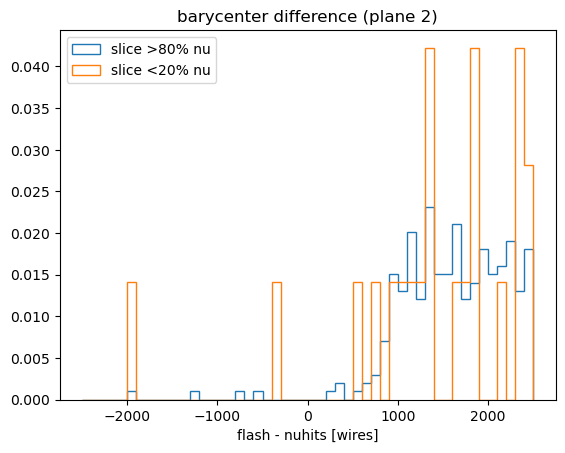

In [19]:
v1 = opflash.query('nuhits/slicehits > 0.8').eval("wire_pos_2-sl_hits_baryc_2")
v2 = opflash.query('nuhits/slicehits < 0.2').eval("wire_pos_2-sl_hits_baryc_2")
plt.hist(v1,np.linspace(-2500,2500,51),weights=NormOne(v1),label='slice >80% nu',histtype='step')
plt.hist(v2,np.linspace(-2500,2500,51),weights=NormOne(v2),label='slice <20% nu',histtype='step')
plt.legend()
plt.xlabel("flash - nuhits [wires]")
plt.title("barycenter difference (plane 2)")
plt.show()

We can repeat the exercise, but this time working in cartesian coordinates and normalizing the difference by the flash width.

In [20]:
opflash['sl_hits_baryc_y'] = opflash.apply(lambda x: wireCrossingYZ(0,x.sl_hits_baryc_0,2,x.sl_hits_baryc_2)[0] if doWiresCross(0,x.sl_hits_baryc_0,2,x.sl_hits_baryc_2) else 999, axis=1)
opflash['sl_hits_baryc_z'] = opflash.apply(lambda x: wireCrossingYZ(0,x.sl_hits_baryc_0,2,x.sl_hits_baryc_2)[1] if doWiresCross(0,x.sl_hits_baryc_0,2,x.sl_hits_baryc_2) else 999, axis=1)

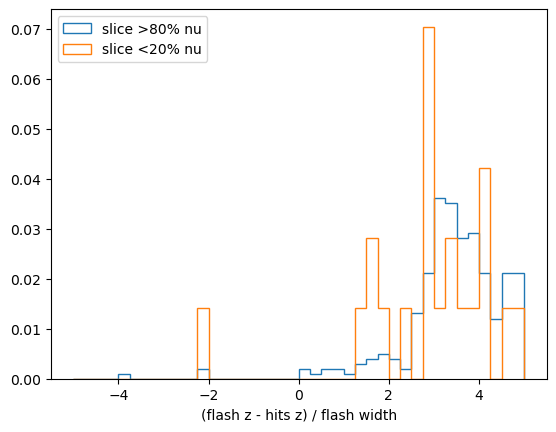

In [21]:
v1 = opflash.query('nuhits/slicehits > 0.8').eval("(z_center-sl_hits_baryc_z)/z_width")
v2 = opflash.query('nuhits/slicehits < 0.2').eval("(z_center-sl_hits_baryc_z)/z_width")
plt.hist(v1,np.linspace(-5,5,41),weights=NormOne(v1),label='slice >80% nu',histtype='step')
plt.hist(v2,np.linspace(-5,5,41),weights=NormOne(v2),label='slice <20% nu',histtype='step')
plt.legend()
plt.xlabel("(flash z - hits z) / flash width")
plt.show()

Another meaningful comparison is between the total light in the flash and the total charge in the slice, and correcting for the position in the detector of the slice (in terms of time=x=distance from the PMT plane).

In [ ]:
sl_hits_charge = hits[["evt_idx","slice_id"]].drop_duplicates()
sl_hits_time   = hits[["evt_idx","slice_id"]].drop_duplicates()

for p in range(0,nplanes()):
    slhitsbyevt_p = hits.query('local_plane==%i'%p).groupby(["evt_idx","slice_id"])
    sl_hits_charge_p = slhitsbyevt_p.apply(lambda x: np.sum(x.integral)).reset_index().rename(columns={0:'sl_hits_charge_%i'%p})
    sl_hits_time_p = slhitsbyevt_p.apply(lambda x: barycenter(x.local_time,x.integral)).reset_index().rename(columns={0:'sl_hits_time_%i'%p})
    sl_hits_charge = sl_hits_charge.merge(sl_hits_charge_p, on=["evt_idx","slice_id"], how="right")
    sl_hits_time = sl_hits_time.merge(sl_hits_time_p, on=["evt_idx","slice_id"], how="right")

opflash = opflash.merge(sl_hits_time, on=["evt_idx","slice_id"], how="right")
opflash = opflash.merge(sl_hits_charge, on=["evt_idx","slice_id"], how="right")

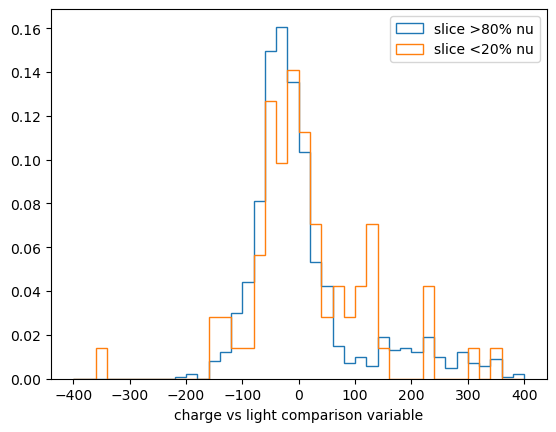

In [23]:
xb = np.linspace(-400,400,41)
slgt08 = opflash.query('nuhits/slicehits > 0.8')
sllt02 = opflash.query('nuhits/slicehits < 0.2')
v1 = 270*np.log10(slgt08.eval("sl_hits_charge_2/totalpe"))-tpcTimeToX(slgt08["sl_hits_time_2"])-250
v2 = 270*np.log10(sllt02.eval("sl_hits_charge_2/totalpe"))-tpcTimeToX(sllt02["sl_hits_time_2"])-250
plt.hist(v1,bins=xb,weights=NormOne(v1),label='slice >80% nu',histtype='step')
plt.hist(v2,bins=xb,weights=NormOne(v2),label='slice <20% nu',histtype='step')
plt.xlabel('charge vs light comparison variable')
plt.legend()
plt.show()

A more advanced metric is available within the collaboration, which compares the light at each PMT as it is measured with the expected light based on the hit positions in the slice. This tool is based on a voxelized look-up library created from a detailed Geant4 simulation to model photon propagation. The resulting discriminator is stored in the flashmatch_score column within the pandoraPrimary table.

In [24]:
# pandoraPrimary_table is not present in .gnn.h5 files; synthesize a proxy table
primary = opflash[["evt_idx", "slice_id", "totalpe"]].copy()
primary["flashmatch_score"] = 100.0 / (1.0 + np.log10(primary["totalpe"].clip(lower=1.0)))
primary = primary.merge(slhits, on=["evt_idx","slice_id"], how="left")

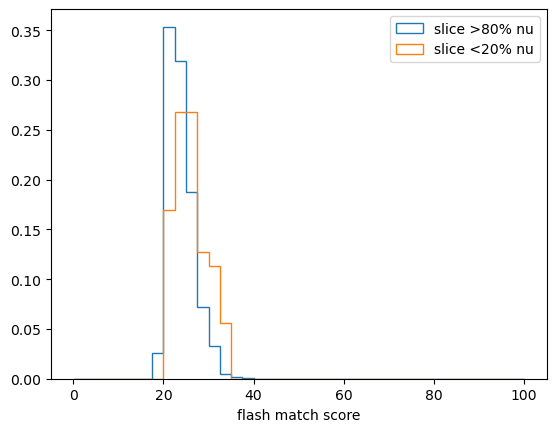

In [25]:
v1 = primary.query('nuhits/slicehits > 0.8').eval("flashmatch_score")
v2 = primary.query('nuhits/slicehits < 0.2').eval("flashmatch_score")
plt.hist(v1,np.linspace(0,100,41),weights=NormOne(v1),label='slice >80% nu',histtype='step')
plt.hist(v2,np.linspace(0,100,41),weights=NormOne(v2),label='slice <20% nu',histtype='step')
plt.legend()
plt.xlabel("flash match score")
plt.show()